In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import noctiluca as nl
import bild
#import bayesmsd

from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'
%config InlineBackend.figure_format='retina'

from pathlib import Path

## load the tracks
all_tracks = pd.read_csv('../all_tracks.csv', index_col=0)

## write a function to grab the data for a given condition and ∆t (in the proper format for BILD)
def generate_data_list(condition, delta_t):
    filenames = all_tracks.loc[(all_tracks['condition']==condition) & (all_tracks['delta_t']==delta_t), 'path']

    data_list = []

    for filename in filenames:
        table_full = pd.read_csv(filename)
        table_xyz = np.array([table_full['pro_x (nm)']-table_full['enh_x (nm)'],
                            table_full['pro_y (nm)']-table_full['enh_y (nm)'],
                            table_full['pro_z (nm)']-table_full['enh_z (nm)']]).T / 1000  # convert to µm
        data_list.append(table_xyz)

    return data_list

/home/jjusuf/miniconda3/envs/bild/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jjusuf/miniconda3/envs/bild/lib/python3.9/site-packages/bild/cython_imports.py:6: UserWarning: Did not find compiled code for MSRouse_logL, falling back to python
  warn("Did not find compiled code for MSRouse_logL, falling back to python")


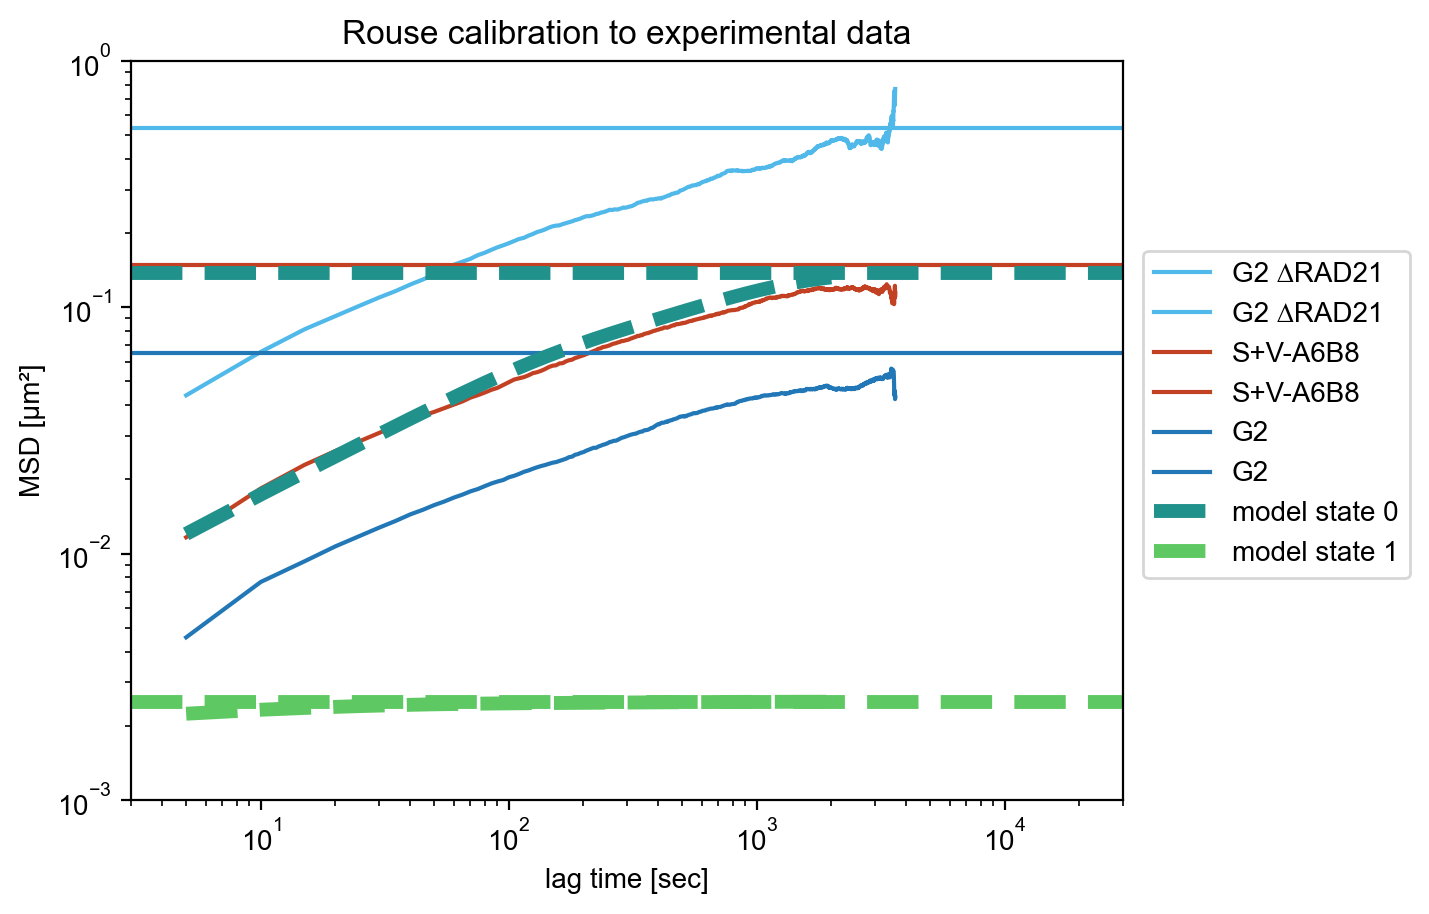

In [74]:
##  MAKE PLOT FOR 5 SECONDS  ##

L = 16
D = 0.00239
k = 1.67
L_looped = 0.297

sigma_spot_dict = {}
sigma_spot_dict['dRAD21'] = np.array([0.084, 0.070, 0.070])
sigma_spot_dict['dCTCF'] = np.array([0.055, 0.053, 0.052])
sigma_spot_dict['regular'] = np.array([0.044, 0.040, 0.044])

w = np.zeros(3*L+1) # total number of monomers: 3*L + 1

w[L] = -1           # designate "measurement vector" w:
w[2*L] = 1          # the observable generated from a conformation x is the scalar product w.x
                    # So w = (0, ..., 0, -1, 0, ..., 0, 1, 0, ...) means we measure
                    # the vector monomer[j] - monomer[i]

model = bild.models.MultiStateRouse(3*L+1, D, k,
                                    looppositions = [None, (L, 2*L, 1/L_looped)],       # define "states" (here: 0=unlooped, 1=looped)
                                    measurement = w,
                                    localization_error = np.sqrt(2)*sigma_spot_dict['regular'], # convert error back to distance
                                   )

colors = {
    'regular' : '#2277B7',
    'dRAD21' : '#50B9E9',
    'dCTCF' : '#C24122',
}

dt = 5  # sec / frame

data_dict = {'dRAD21': generate_data_list('G7B8G2_GSK_RAD21depletion', 5),
             'dCTCF': generate_data_list('S+V-A6B8_GSK', 5),
             'regular': generate_data_list('G7B8G2_GSK', 5)}

# "Empirical" MSDs
for tag, color, label in [('dRAD21', colors['dRAD21'], 'G2 ∆RAD21'),
                          ('dCTCF', colors['dCTCF'], 'S+V-A6B8'),
                          ('regular', colors['regular'], 'G2'),
                                 ]:
    sigma2 = 2*np.sum(np.square(sigma_spot_dict[tag]))
    curr_data_nl_format = nl.util.userinput.make_TaggedSet(data_dict[tag])
    msd = nl.analysis.MSD(curr_data_nl_format) - 2*sigma2
    ss = np.nanmean(np.concatenate([traj.abs()[:][:, 0]**2 for traj in curr_data_nl_format])) - sigma2
    
    plt.plot(dt*np.arange(1, len(msd)), msd[1:],
             color=color, label=label,
            )
    plt.axhline(2*ss,
                color=color, label=label,
               )

# Model states
plot_range = np.arange(1, 400)
for i, state_model in enumerate(model.models):
    color = plt.cm.viridis(0.5*(1+i/len(model.models)))
    
    plt.plot(dt*plot_range, state_model.MSD(plot_range, w=model.measurement),
             color=color,
             label=f"model state {i}",
             linewidth=5,
             linestyle='--'
            )
    plt.axhline(state_model.MSD(np.inf, w=model.measurement),
                color=color,
                linewidth=5,
                linestyle='--'
               )
    
plt.legend(loc=(1.02, 0.3))
plt.xlabel('lag time [sec]')
plt.ylabel('MSD [μm²]')
plt.title('Rouse calibration to experimental data')
plt.xscale('log')
plt.yscale('log')
plt.xlim(3, 30000);
plt.ylim(1e-3, 1);
plt.show()


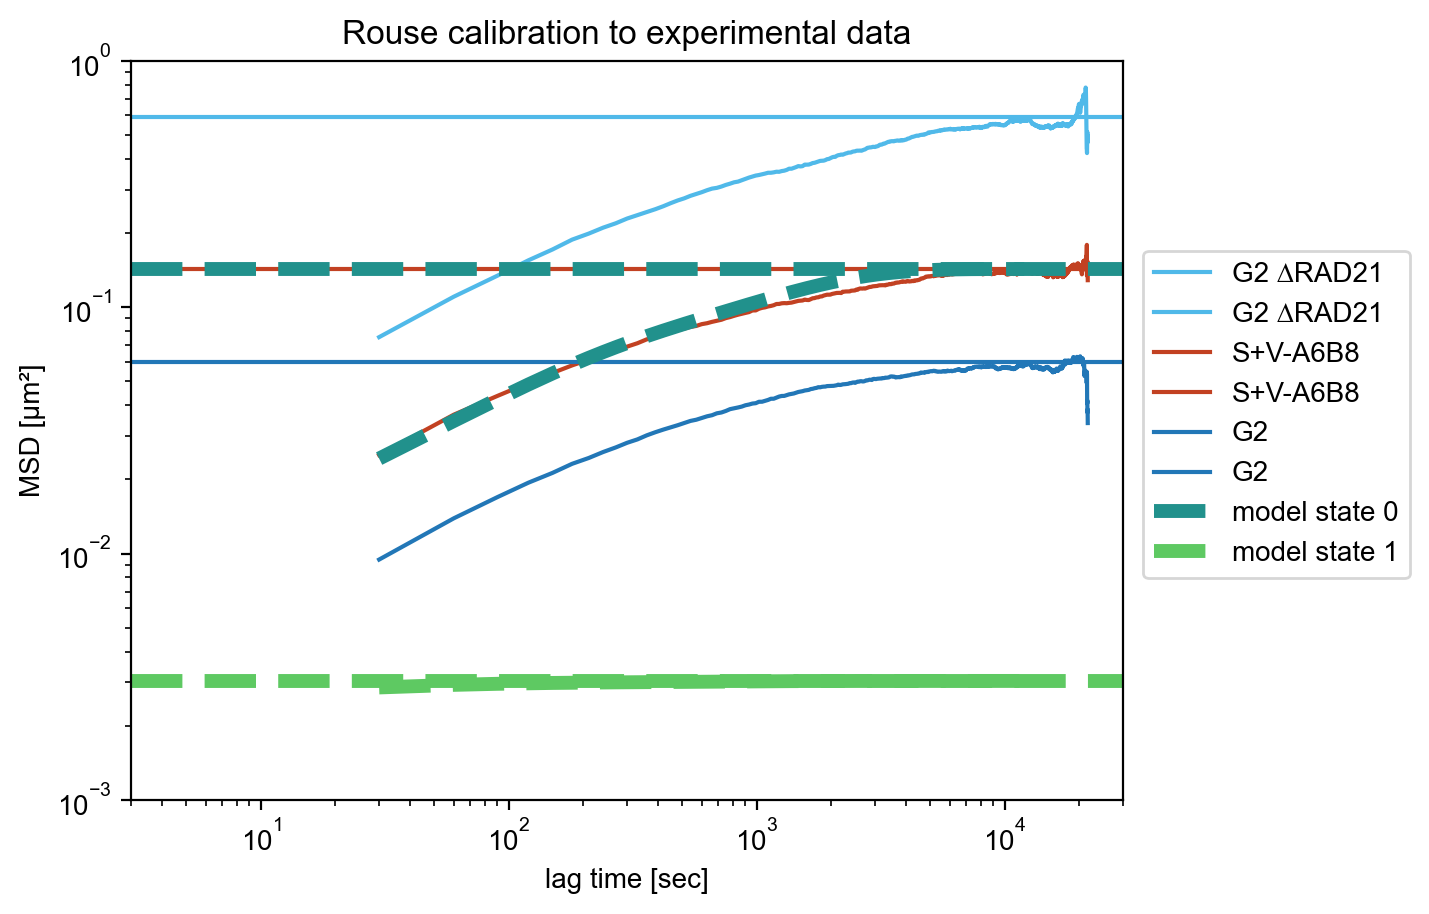

In [55]:
##  MAKE PLOT FOR 30 SECONDS  ##

L = 16
D = 0.00884
k = 5.94
L_looped = 0.348

sigma_spot_dict = {}
sigma_spot_dict['dRAD21'] = np.array([0.092, 0.088, 0.069])
sigma_spot_dict['dCTCF'] =  np.array([0.062, 0.064, 0.063])
sigma_spot_dict['regular'] = np.array([0.047, 0.046, 0.046])

w = np.zeros(3*L+1) # total number of monomers: 3*L + 1

w[L] = -1           # designate "measurement vector" w:
w[2*L] = 1          # the observable generated from a conformation x is the scalar product w.x
                    # So w = (0, ..., 0, -1, 0, ..., 0, 1, 0, ...) means we measure
                    # the vector monomer[j] - monomer[i]

model = bild.models.MultiStateRouse(3*L+1, D, k,
                                    looppositions = [None, (L, 2*L, 1/L_looped)],       # define "states" (here: 0=unlooped, 1=looped)
                                    measurement = w,
                                    localization_error = np.sqrt(2)*sigma_spot_dict['regular'], # convert error back to distance
                                   )

colors = {
    'regular' : '#2277B7',
    'dRAD21' : '#50B9E9',
    'dCTCF' : '#C24122',
}

dt = 30  # sec / frame

data_dict = {'dRAD21': generate_data_list('G7B8G2_GSK_RAD21depletion', 30),
             'dCTCF': generate_data_list('S+V-A6B8_GSK', 30),
             'regular': generate_data_list('G7B8G2_GSK', 30)}

# "Empirical" MSDs
for tag, color, label in [('dRAD21', colors['dRAD21'], 'G2 ∆RAD21'),
                          ('dCTCF', colors['dCTCF'], 'S+V-A6B8'),
                          ('regular', colors['regular'], 'G2'),
                                 ]:
    sigma2 = 2*np.sum(np.square(sigma_spot_dict[tag]))
    curr_data_nl_format = nl.util.userinput.make_TaggedSet(data_dict[tag])
    msd = nl.analysis.MSD(curr_data_nl_format) - 2*sigma2
    ss = np.nanmean(np.concatenate([traj.abs()[:][:, 0]**2 for traj in curr_data_nl_format])) - sigma2
    
    plt.plot(dt*np.arange(1, len(msd)), msd[1:],
             color=color, label=label,
            )
    plt.axhline(2*ss,
                color=color, label=label,
               )

# Model states
plot_range = np.arange(1, 400)
for i, state_model in enumerate(model.models):
    color = plt.cm.viridis(0.5*(1+i/len(model.models)))
    
    plt.plot(dt*plot_range, state_model.MSD(plot_range, w=model.measurement),
             color=color,
             label=f"model state {i}",
             linewidth=5,
             linestyle='--'
            )
    plt.axhline(state_model.MSD(np.inf, w=model.measurement),
                color=color,
                linewidth=5,
                linestyle='--'
               )

plt.legend(loc=(1.02, 0.3))
plt.xlabel('lag time [sec]')
plt.ylabel('MSD [μm²]')
plt.title('Rouse calibration to experimental data')
plt.xscale('log')
plt.yscale('log')
plt.xlim(3, 30000);
plt.ylim(1e-3, 1);
plt.show()


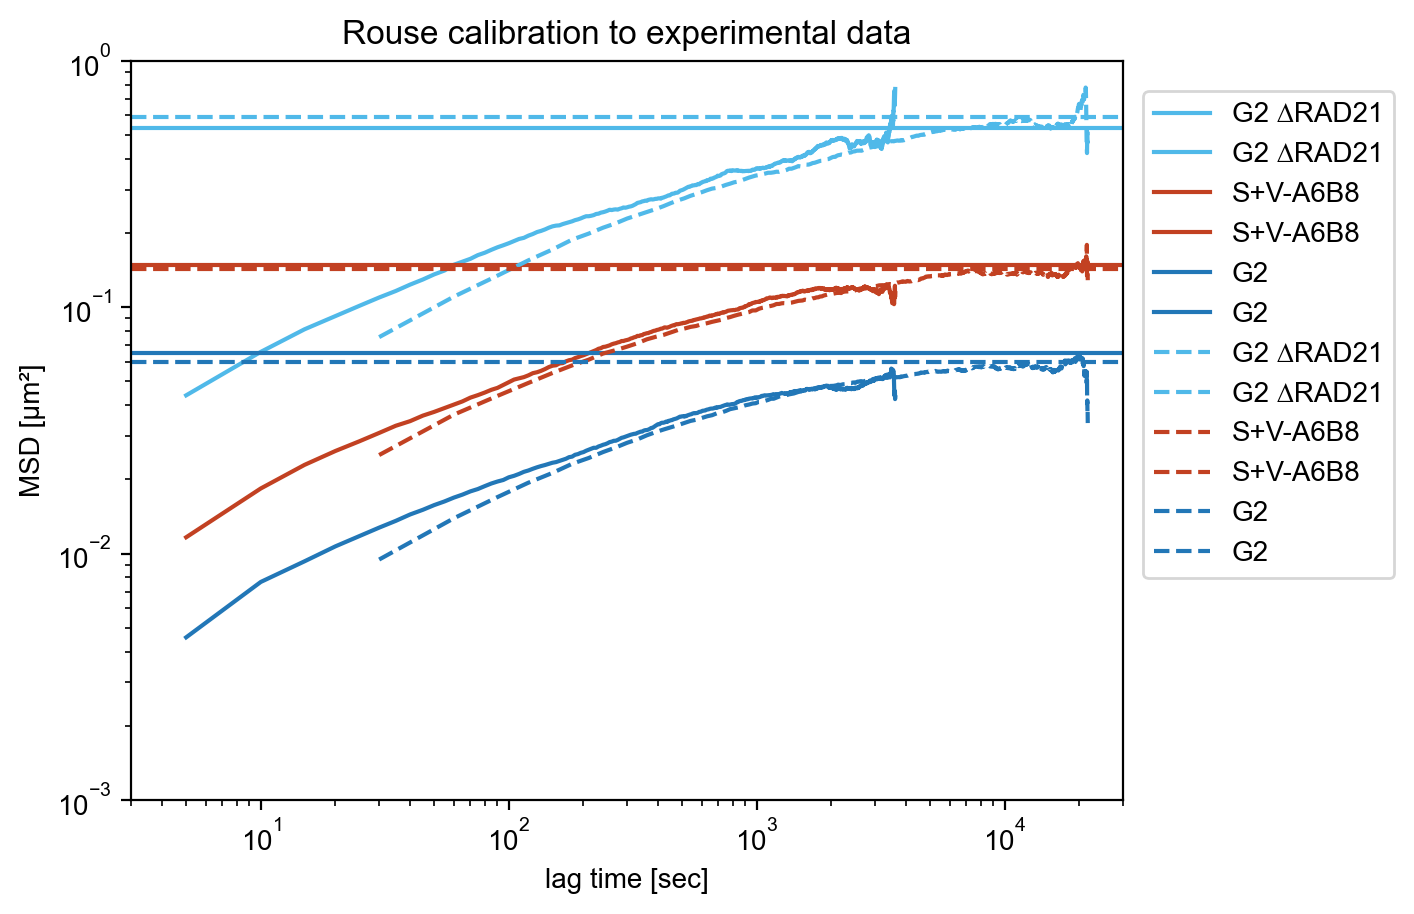

In [76]:
##  MAKE PLOT FOR 5 SECONDS  ##

L = 16
D = 0.00239
k = 1.67
L_looped = 0.297

sigma_spot_dict = {}
sigma_spot_dict['dRAD21'] = np.array([0.084, 0.070, 0.070])
sigma_spot_dict['dCTCF'] = np.array([0.055, 0.053, 0.052])
sigma_spot_dict['regular'] = np.array([0.044, 0.040, 0.044])

w = np.zeros(3*L+1) # total number of monomers: 3*L + 1

w[L] = -1           # designate "measurement vector" w:
w[2*L] = 1          # the observable generated from a conformation x is the scalar product w.x
                    # So w = (0, ..., 0, -1, 0, ..., 0, 1, 0, ...) means we measure
                    # the vector monomer[j] - monomer[i]

model = bild.models.MultiStateRouse(3*L+1, D, k,
                                    looppositions = [None, (L, 2*L, 1/L_looped)],       # define "states" (here: 0=unlooped, 1=looped)
                                    measurement = w,
                                    localization_error = np.sqrt(2)*sigma_spot_dict['regular'], # convert error back to distance
                                   )

colors = {
    'regular' : '#2277B7',
    'dRAD21' : '#50B9E9',
    'dCTCF' : '#C24122',
}

dt = 5  # sec / frame

data_dict = {'dRAD21': generate_data_list('G7B8G2_GSK_RAD21depletion', 5),
             'dCTCF': generate_data_list('S+V-A6B8_GSK', 5),
             'regular': generate_data_list('G7B8G2_GSK', 5)}

# "Empirical" MSDs
for tag, color, label in [('dRAD21', colors['dRAD21'], 'G2 ∆RAD21'),
                          ('dCTCF', colors['dCTCF'], 'S+V-A6B8'),
                          ('regular', colors['regular'], 'G2'),
                                 ]:
    sigma2 = 2*np.sum(np.square(sigma_spot_dict[tag]))
    curr_data_nl_format = nl.util.userinput.make_TaggedSet(data_dict[tag])
    msd = nl.analysis.MSD(curr_data_nl_format) - 2*sigma2
    ss = np.nanmean(np.concatenate([traj.abs()[:][:, 0]**2 for traj in curr_data_nl_format])) - sigma2
    
    plt.plot(dt*np.arange(1, len(msd)), msd[1:],
             color=color, label=label,
            )
    plt.axhline(2*ss,
                color=color, label=label,
               )
    
##  MAKE PLOT FOR 30 SECONDS  ##

L = 16
D = 0.00884
k = 5.94
L_looped = 0.348

sigma_spot_dict = {}
sigma_spot_dict['dRAD21'] = np.array([0.092, 0.088, 0.069])
sigma_spot_dict['dCTCF'] =  np.array([0.062, 0.064, 0.063])
sigma_spot_dict['regular'] = np.array([0.047, 0.046, 0.046])

w = np.zeros(3*L+1) # total number of monomers: 3*L + 1

w[L] = -1           # designate "measurement vector" w:
w[2*L] = 1          # the observable generated from a conformation x is the scalar product w.x
                    # So w = (0, ..., 0, -1, 0, ..., 0, 1, 0, ...) means we measure
                    # the vector monomer[j] - monomer[i]

model = bild.models.MultiStateRouse(3*L+1, D, k,
                                    looppositions = [None, (L, 2*L, 1/L_looped)],       # define "states" (here: 0=unlooped, 1=looped)
                                    measurement = w,
                                    localization_error = np.sqrt(2)*sigma_spot_dict['regular'], # convert error back to distance
                                   )

colors = {
    'regular' : '#2277B7',
    'dRAD21' : '#50B9E9',
    'dCTCF' : '#C24122',
}

dt = 30  # sec / frame

data_dict = {'dRAD21': generate_data_list('G7B8G2_GSK_RAD21depletion', 30),
             'dCTCF': generate_data_list('S+V-A6B8_GSK', 30),
             'regular': generate_data_list('G7B8G2_GSK', 30)}

# "Empirical" MSDs
for tag, color, label in [('dRAD21', colors['dRAD21'], 'G2 ∆RAD21'),
                          ('dCTCF', colors['dCTCF'], 'S+V-A6B8'),
                          ('regular', colors['regular'], 'G2'),
                                 ]:
    sigma2 = 2*np.sum(np.square(sigma_spot_dict[tag]))
    curr_data_nl_format = nl.util.userinput.make_TaggedSet(data_dict[tag])
    msd = nl.analysis.MSD(curr_data_nl_format) - 2*sigma2
    ss = np.nanmean(np.concatenate([traj.abs()[:][:, 0]**2 for traj in curr_data_nl_format])) - sigma2
    
    plt.plot(dt*np.arange(1, len(msd)), msd[1:],
             color=color, label=label, linestyle='--',
            )
    plt.axhline(2*ss,
                color=color, label=label, linestyle='--',
               )

plt.legend(loc=(1.02, 0.3))
plt.xlabel('lag time [sec]')
plt.ylabel('MSD [μm²]')
plt.title('Rouse calibration to experimental data')
plt.xscale('log')
plt.yscale('log')
plt.xlim(3, 30000);
plt.ylim(1e-3, 1);
plt.show()


# Histograms

In [ ]:
import pandas as pd 
import numpy as np

import noctiluca as nl
import bild
import bayesmsd

from pathlib import Path

## load the tracks
all_tracks = pd.read_csv('../all_tracks.csv', index_col=0)

## write a function to grab the data for a given condition and ∆t (in the proper format for BILD)
def generate_data_list(condition, delta_t):
    filenames = all_tracks.loc[(all_tracks['condition']==condition) & (all_tracks['delta_t']==delta_t), 'path']

    data_list = []

    for filename in filenames:
        table_full = pd.read_csv(filename)
        table_xyz = np.array([table_full['pro_x (nm)']-table_full['enh_x (nm)'],
                            table_full['pro_y (nm)']-table_full['enh_y (nm)'],
                            table_full['pro_z (nm)']-table_full['enh_z (nm)']]).T / 1000  # convert to µm
        data_list.append(table_xyz)

    return data_list

/home/jjusuf/miniconda3/envs/bild/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jjusuf/miniconda3/envs/bild/lib/python3.9/site-packages/bild/cython_imports.py:6: UserWarning: Did not find compiled code for MSRouse_logL, falling back to python
  warn("Did not find compiled code for MSRouse_logL, falling back to python")


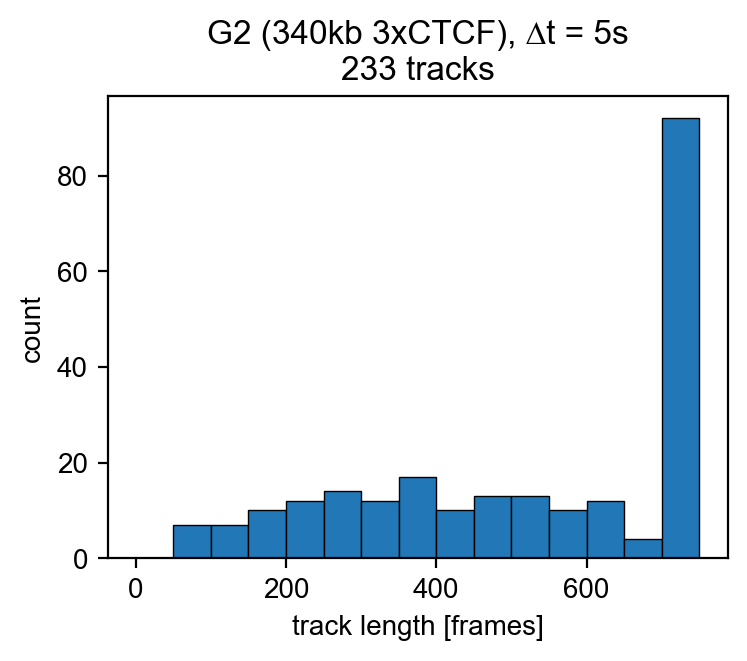

In [42]:
data_list = generate_data_list('G7B8G2_GSK', 5)
plt.figure(figsize=(4,3))
plt.hist([len(data) for data in data_list], bins=np.arange(0,751,50), linewidth=0.5, edgecolor='black', color='#2277B7');
plt.xlabel('track length [frames]')
plt.ylabel('count')
plt.title(f'G2 (340kb 3xCTCF), ∆t = 5s\n{len(data_list)} tracks');

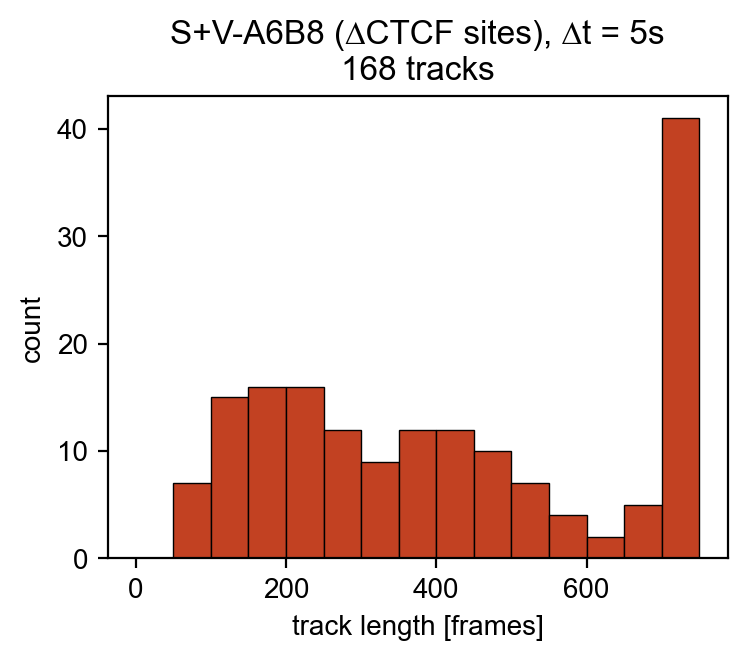

In [43]:
data_list = generate_data_list('S+V-A6B8_GSK', 5)
plt.figure(figsize=(4,3))
plt.hist([len(data) for data in data_list], bins=np.arange(0,751,50), linewidth=0.5, edgecolor='black', color='#C24122');
plt.xlabel('track length [frames]')
plt.ylabel('count')
plt.title(f'S+V-A6B8 (∆CTCF sites), ∆t = 5s\n{len(data_list)} tracks');

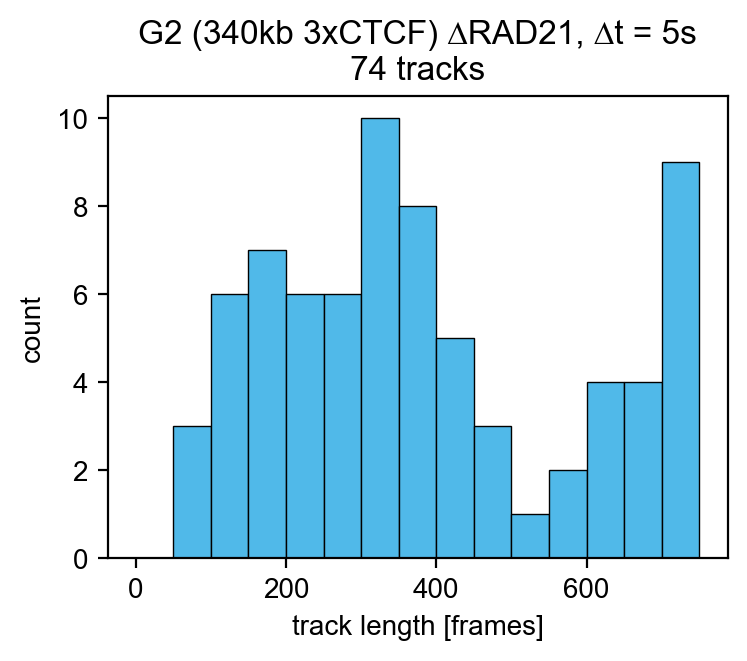

In [44]:
data_list = generate_data_list('G7B8G2_GSK_RAD21depletion', 5)
plt.figure(figsize=(4,3))
plt.hist([len(data) for data in data_list], bins=np.arange(0,751,50), linewidth=0.5, edgecolor='black', color='#50B9E9');
plt.xlabel('track length [frames]')
plt.ylabel('count')
plt.title(f'G2 (340kb 3xCTCF) ∆RAD21, ∆t = 5s\n{len(data_list)} tracks');